# Escolha da janela de anos (2023-2025)

Este notebook verifica se 2023, 2024 e 2025 podem compor a janela de análise
da base e gera a **Figura 1** do artigo.

**Risco avaliado.** Os dados criminais provêm da SSP-SP (Secretaria da
Segurança Pública do Estado de São Paulo), que entre 2022 e 2023 substituiu o
R.D.O. (Registro Digital de Ocorrências) pelo S.P.J. (Sistema de Polícia
Judiciária). A troca altera a forma de registro, não a incidência criminal.
Caso os dois sistemas contabilizem de modos distintos, a comparação entre 2022
e 2023 atribuiria à criminalidade uma variação de origem administrativa.

**Critério adotado**, definido previamente de modo a evitar a escolha
posterior da conclusão mais conveniente:

- salto na série mensal entre dez/2022 e jan/2023: a troca de sistema ainda
  afetava os números e a janela passa a ser 2024-2025;
- ausência de salto: a janela 2023-2025 fica confirmada.

**Dados.** Arquivo `data/processed/ssp_painel.csv`, gerado pelo `main.py` com
as ocorrências agregadas por município, ano e mês. Os arquivos originais da
SSP não são relidos aqui em razão do volume.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Os notebooks ficam em notebooks/ e o código do projeto em src/. Estas duas
# linhas apontam o Python para src/, para os "from config import ..." abaixo
# funcionarem tanto rodando daqui quanto da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from config import SSP_PAINEL_CSV, GRUPOS_NATUREZA
from estilo import aplicar_estilo, salvar
from figuras import plot_serie_mensal
from parse_ssp import normaliza

aplicar_estilo()   # mesma fonte, cores e grade em todas as figuras do artigo
# Se algum import acima falhar, quase sempre é o editor apontando para outra
# instalação do Python. O caminho impresso aqui é o que precisa ter as
# bibliotecas do requirements.txt.
print("Python:", sys.executable)

# O código do IBGE é identificador, não quantidade: lido como texto para não
# virar número em nenhuma etapa.
painel = pd.read_csv(SSP_PAINEL_CSV, dtype={"codigo_ibge": str})
print(painel.shape, "| anos:", sorted(painel["ano"].unique()))

Python: c:\Users\Higor\Documents\6 Sem\RP2\projeto\database-rp2\.venv\Scripts\python.exe
(199472, 5) | anos: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


## 1. Completude da série

Um mês ausente produz na série o mesmo efeito visual de uma queda real, de
modo que a completude precisa ser verificada antes da inspeção gráfica.

São duas conferências: o volume de ocorrências sem mês preenchido, marcadas
com `mes = 0`, que permanecem no total anual mas não se posicionam na linha do
tempo; e a presença dos doze meses em cada ano.

In [2]:
sem_mes = painel.loc[painel["mes"] == 0, "ocorrencias"].sum()
print(f"ocorrências sem mês: {sem_mes} de {painel['ocorrencias'].sum():,}")

# nunique() conta quantos meses diferentes cada ano tem. O esperado é 12.
meses_por_ano = painel[painel["mes"] > 0].groupby("ano")["mes"].nunique()
print(meses_por_ano.to_string())
# O assert derruba o notebook se faltar mês, em vez de deixar a gente
# interpretar um gráfico furado como se fosse um resultado.
assert (meses_por_ano == 12).all(), "algum ano não tem os 12 meses"

ocorrências sem mês: 0 de 4,792,830
ano
2022    12
2023    12
2024    12
2025    12


## 2. Figura 1 - total mensal de ocorrências, 2022 a 2025

A linha vertical marca janeiro de 2023, início da janela, ponto em que um
eventual salto se manifestaria.

O eixo vertical inicia em zero de maneira a preservar a proporção real das
oscilações: eixos truncados convertem variações de poucos pontos percentuais
em degraus aparentes.

-> figuras/figura1_serie_mensal.png


WindowsPath('C:/Users/Higor/Documents/6 Sem/RP2/projeto/database-rp2/figuras/figura1_serie_mensal.png')

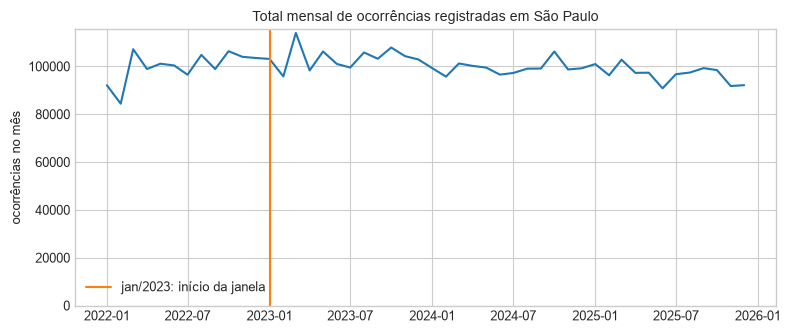

In [3]:
fig = plot_serie_mensal(painel)
salvar(fig, "figura1_serie_mensal")

## 3. Série desagregada por natureza criminal

O total agregado pode ocultar movimentos opostos, como uma queda no furto
compensada por alta no roubo.

Cada painel tem escala própria, dada a diferença de magnitude entre as
naturezas. A leitura relevante é o **formato** das linhas na virada do ano, e
não a altura delas.

-> figuras/figura1b_serie_por_natureza.png


WindowsPath('C:/Users/Higor/Documents/6 Sem/RP2/projeto/database-rp2/figuras/figura1b_serie_por_natureza.png')

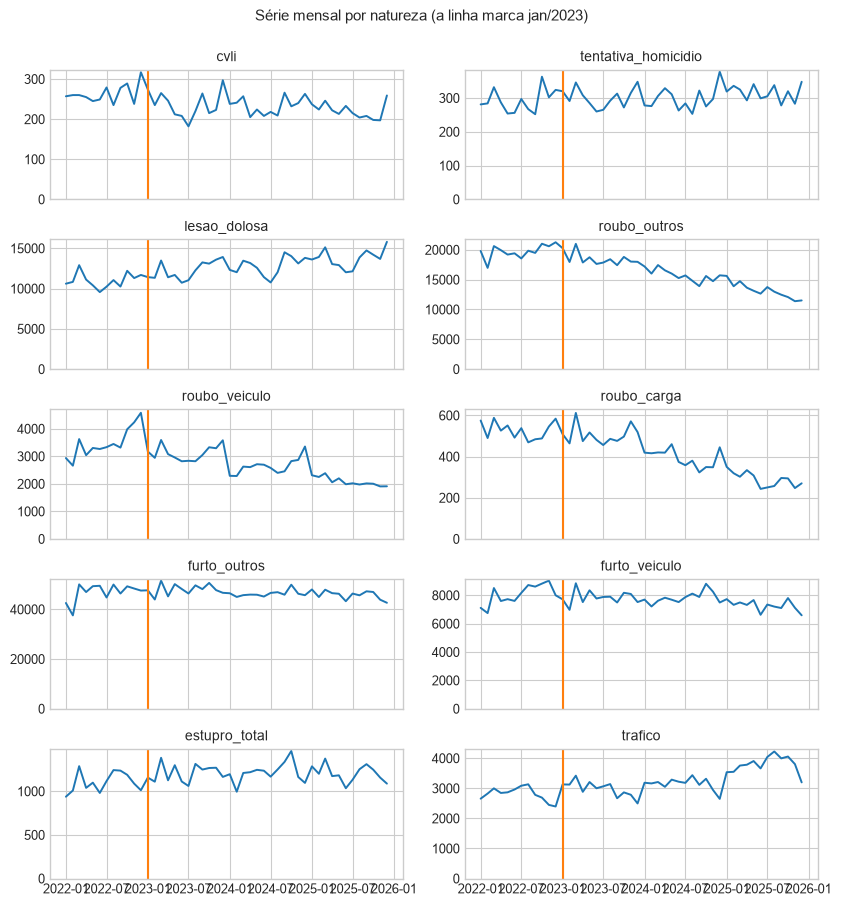

In [4]:
fig = plot_serie_mensal(painel, GRUPOS_NATUREZA)
salvar(fig, "figura1b_serie_por_natureza")

## 4. Verificação numérica

Dois fatores limitam a inspeção visual: a sazonalidade, que altera o nível a
cada passagem de dezembro para janeiro, e a dificuldade de identificar saltos
pequenos distribuídos em dez painéis.

O teste é, portanto, comparativo. Para cada natureza criminal calcula-se a
variação percentual anual, de modo a verificar duas condições:

1. a variação de 2022 para 2023 é **superior** à das demais viradas de ano?
2. ela ocorre na **mesma direção** em todas as naturezas?

Uma troca de sistema de registro produziria as duas condições
simultaneamente, por atingir todas as naturezas de uma vez; sazonalidade e
variação ordinária, não.

In [5]:
# GRUPOS_NATUREZA (config.py) diz quais rubricas da SSP formam cada grupo.
# Aqui o dicionário é invertido para "rubrica -> grupo". normaliza() tira
# acento e caixa, porque o texto da planilha muda de um ano para o outro.
mapa = {normaliza(nat): g for g, lista in GRUPOS_NATUREZA.items() for nat in lista}
# O dropna descarta as rubricas que o projeto não usa (trânsito, porte de
# arma), que ficaram sem grupo no map acima.
bloco = painel.assign(grupo=painel["natureza"].map(mapa)).dropna(subset=["grupo"])

# unstack("ano") joga os anos para as colunas: uma linha por grupo de crime,
# uma coluna por ano.
anual = bloco.groupby(["grupo", "ano"])["ocorrencias"].sum().unstack("ano")
# pct_change(axis=1) compara cada ano com o da coluna anterior. A primeira
# coluna sai (iloc[:, 1:]) porque não tem ano anterior com que comparar.
variacao = (anual.pct_change(axis=1) * 100).round(1).iloc[:, 1:]
variacao.columns = [f"{a - 1}→{a}" for a in anual.columns[1:]]
variacao

,2022→2023,2023→2024,2024→2025
grupo,,,
cvli,-10.2,-1.4,-5.2
estupro_total,9.6,0.4,-0.9
furto_outros,2.4,-3.6,-1.0
furto_veiculo,-2.5,-0.3,-7.1
lesao_dolosa,11.4,4.1,7.7
roubo_carga,-4.2,-22.3,-26.3
roubo_outros,-6.2,-14.9,-16.5
roubo_veiculo,-10.2,-15.4,-21.0
tentativa_homicidio,3.3,-1.2,6.0


In [6]:
primeira = variacao.iloc[:, 0]          # a virada suspeita: 2022-2023
demais = variacao.iloc[:, 1:]           # 2023-2024 e 2024-2025: o padrão normal

# Pergunta 2: se fosse troca de sistema, quase todos os crimes iriam para o
# mesmo lado.
print(f"2022-2023: {(primeira > 0).sum()} naturezas sobem, "
      f"{(primeira < 0).sum()} descem")
# Pergunta 1: o tamanho da variação, sem o sinal (abs), comparado com o das
# viradas normais. O stack() junta as duas colunas de "demais" numa lista só,
# para tirar uma mediana de todas elas de uma vez.
print(f"variação mediana (em módulo): 2022-2023 = {primeira.abs().median():.1f}% | "
      f"demais viradas = {demais.abs().stack().median():.1f}%")

# Critério de "fora do padrão": variar mais que o dobro do que aquele mesmo
# crime costuma variar nas outras viradas de ano.
fora = primeira.abs() > 2 * demais.abs().median(axis=1)
print("naturezas em que 2022-2023 passa do dobro do normal:",
      ", ".join(fora[fora].index) or "nenhuma")

2022-2023: 5 naturezas sobem, 5 descem
variação mediana (em módulo): 2022-2023 = 6.2% | demais viradas = 5.8%
naturezas em que 2022-2023 passa do dobro do normal: cvli, estupro_total


## 5. Conclusão: janela 2023-2025 confirmada

Os quatro resultados convergem.

- A série do total não apresenta salto em janeiro de 2023.
- Na virada de 2022 para 2023, metade das naturezas sobe e metade desce. Uma
  mudança de sistema deslocaria praticamente todas na mesma direção.
- A variação mediana dessa virada equivale à das demais, ou seja, 2022-2023
  não apresenta comportamento excepcional.
- As duas exceções são o CVLI (crimes violentos letais intencionais:
  homicídio doloso, latrocínio e lesão corporal seguida de morte) e o estupro,
  justamente as naturezas de notificação mais obrigatória e menos sujeitas a
  reclassificação. Um efeito de sistema apareceria primeiro no furto e no
  roubo, de maior volume e registro mais burocrático.

Mantém-se `ANOS_JANELA = [2023, 2024, 2025]` no `config.py`. O ano de 2022
permanece apenas no painel intermediário, como referência comparativa, e não
integra a base final.